In [26]:
#importing necessary packages
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

**Task 1**

In [27]:
#Loading Image.
im1=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q1.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im1 is not None

In [28]:
def Intensity_Transform(c):
    parts = []
    for i in range(len(c) - 1):
        x1, y1 = c[i]
        x2, y2 = c[i + 1]
        # Ignore vertical sections
        if x1 == x2:
            continue
        # Values for x1, x1+1, ..., x2-1
        part = np.linspace(y1, y2, x2 - x1 + 1)[:-1]
        parts.append(part)
    # Add output value corresponding to x = 255
    parts.append(np.array([c[-1, 1]]))
    return np.concatenate(parts).astype('uint8')

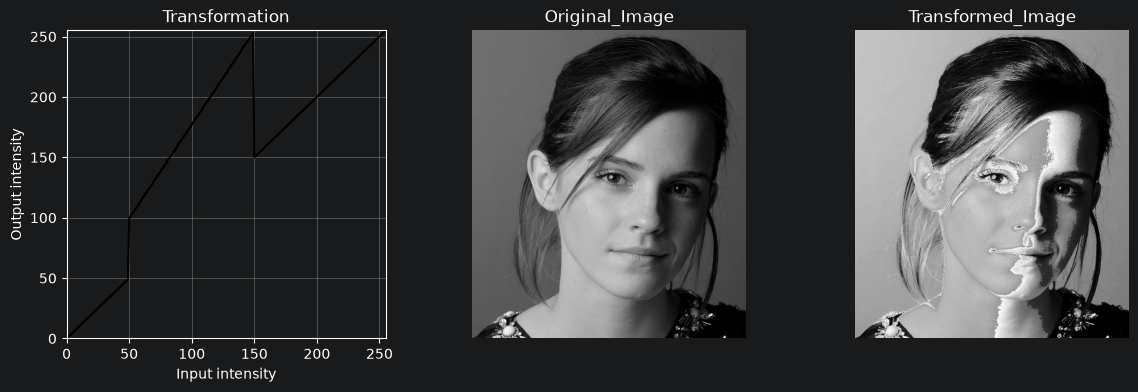

In [36]:
#Defining Intensity Transformation Function (Given Graph)
c = np.array([(0,0),(50,50), (50,100), (150,255), (150,150),(255,255)])
Transformation = Intensity_Transform(c)
Transformed_im = cv.LUT(im1, Transformation)
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Transformation, color='black')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im1,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Transformed_Image')
ax[2].axis('off')
plt.show()

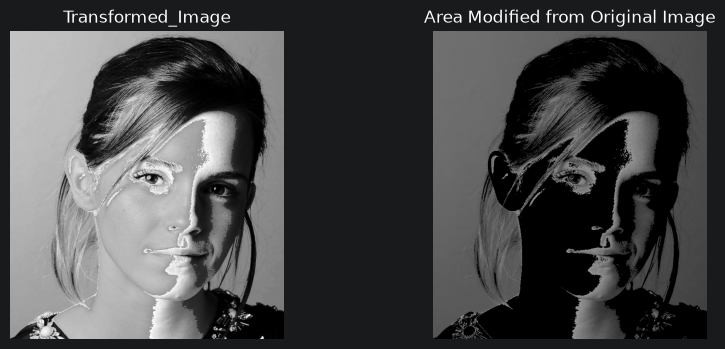

In [35]:
#Verifying Transformation By comparing transformed image with area modified from original image
#Since only intensities between 50 and 150 are modified, we can create a mask to extract that area from the original image and compare it with the transformed image.
c1=np.array([(0,0),(50,0), (50,50), (150,150), (150,0),(255,0)])
Transformation1 = Intensity_Transform(c1)
Transformed_im1 = cv.LUT(im1, Transformation1)
fig,ax = plt.subplots(nrows=1,ncols=2, figsize=(10,4))
ax[0].imshow(Transformed_im,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Transformed_Image')
ax[0].axis('off')
ax[1].imshow(Transformed_im1,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Area Modified from Original Image')
ax[1].axis('off')
plt.show()

**Task 2**

*(a) Accentuating White Matter in Brain MRI Image*

In [38]:
#Loading Brain MRI Image.
im2=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q2.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im2 is not None

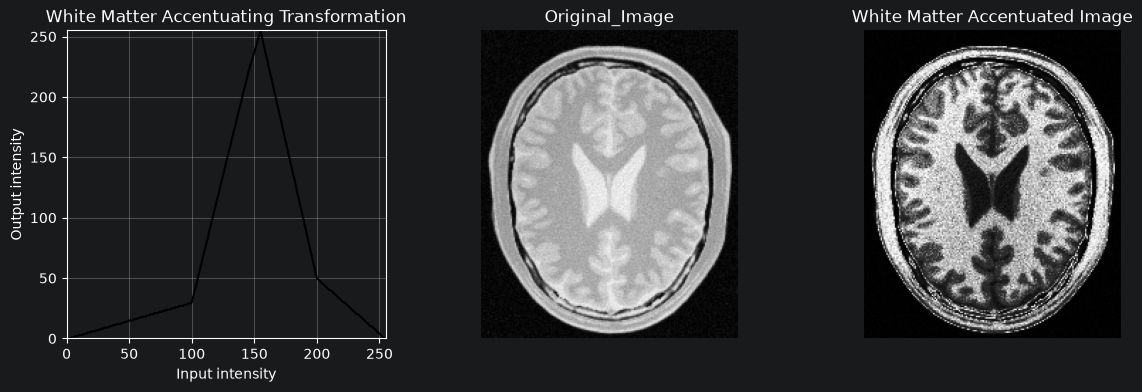

In [75]:
#Defining Break Points for Accentuating White Matter in Brain MRI Image
c_white = np.array([(0,0), (100,30), (145,220), (155,255),(200,50),(255,0)])
Transform_white = Intensity_Transform(c_white)
Transformed_im_white = cv.LUT(im2, Transform_white)
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Transform_white, color='black')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('White Matter Accentuating Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im2,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_white,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('White Matter Accentuated Image')
ax[2].axis('off')
plt.show()

*(b) Accentuating Gray Matter in Brain MRI Image*

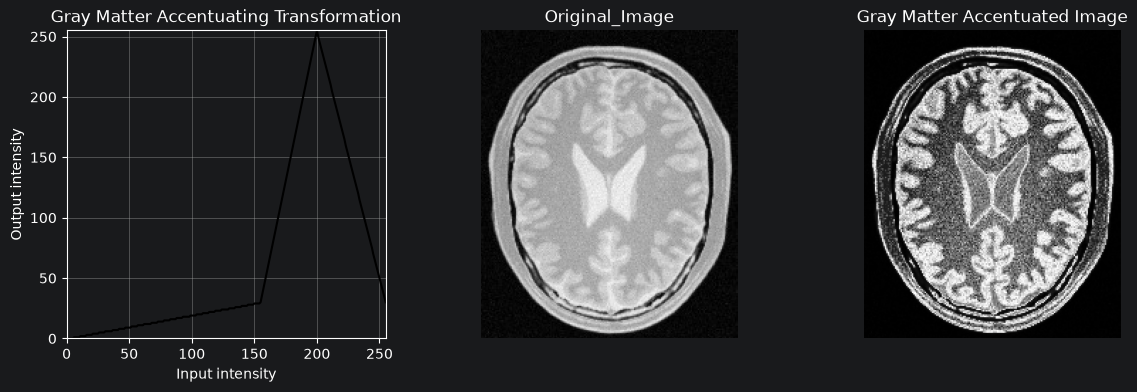

In [74]:
#Defining Break Points for Accentuating Gray Matter in Brain MRI Image
c_gray = np.array([(0,0),(155,30), (200,255), (255,30)])
Transform_gray = Intensity_Transform(c_gray)
Transformed_im_gray = cv.LUT(im2, Transform_gray)
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].plot(Transform_gray, color='black')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Gray Matter Accentuating Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im2,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_gray,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Gray Matter Accentuated Image')
ax[2].axis('off')
plt.show()